Imports

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from adjustText import adjust_text
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

Expression - Import

In [2]:
expression_df = pd.read_csv("C:\\Users\\Ana\\Documents\\Estágio\\Sun2023\\Expression_TE_DESeq.csv")
expression_df.rename(columns = {'Unnamed: 0' : 'TE'}, inplace = True)
expression_df.head()

,TE,WT_rep1,MECP2_rep1,WT_rep2,MECP2_rep2,WT_rep3,MECP2_rep3
0,TE_MIR3_dup1,0,1,6,6,3,0
1,TE_L2a_dup1,0,7,7,6,1,3
2,TE_L3_dup1,5,0,8,3,2,6
3,TE_L2b_dup1,0,0,5,0,2,5
4,TE_Tigger5_dup1,11,3,5,16,3,8


DEA - Import

In [3]:
dea_df = pd.read_csv("C:\\Users\\Ana\\Documents\\Estágio\\Sun2023\\DEA_TE_DESeq.csv")
dea_df.rename(columns = {'Unnamed: 0' : 'TE'}, inplace = True)
dea_df.dropna(subset =['padj'], inplace = True)
dea_df.head()
print(dea_df.columns.tolist())

['TE', 'baseMean', 'log2FoldChange', 'lfcSE', 'stat', 'pvalue', 'padj']


Volcano plot

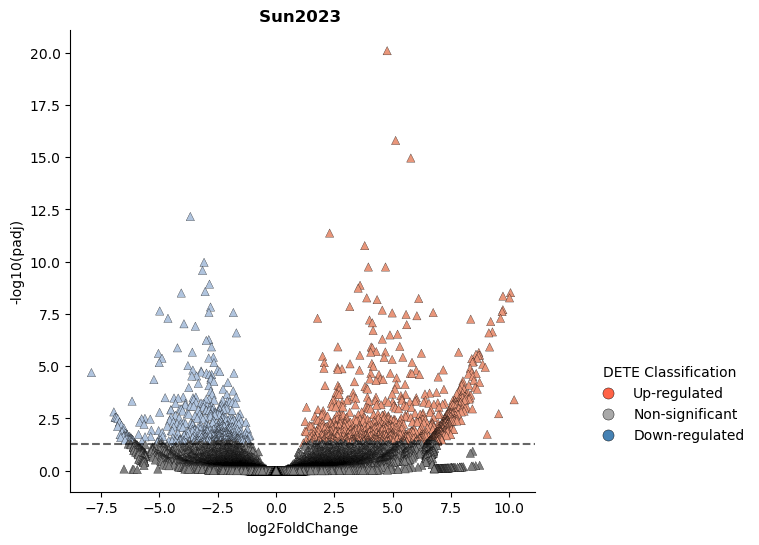

In [4]:
# Global variables
genes_of_interest = None


# Organizes the classification, according to the defined values
def organize_classification():
    dea_df['-log10(padj)'] = -np.log10(dea_df['padj'])

    dea_df['Classification'] = dea_df.apply(
        lambda row:
        'Up-regulated' if (row['log2FoldChange'] > 0.5 and row['padj'] < 0.05)
        else 'Down-regulated' if (row['log2FoldChange'] < -0.5 and row['padj'] < 0.05)
        else 'Non-significant',
        axis = 1
    )

# Sets the graph's reference lines and labels
def set_lines_and_labels(ax):
    ax.axhline(y = -np.log10(0.05), color = 'black', linestyle = '--', alpha = 0.6)

    ax.set_title('Sun2023 ', fontweight = 'bold', fontsize = 12)
    ax.set_xlabel('log2FoldChange')
    ax.set_ylabel('-log10(padj)')

# Gets the genes with the biggest change in expression
def get_genes_of_interest():
    top_up = dea_df.nlargest(5, 'log2FoldChange')['TE'].tolist()
    top_down = dea_df.nsmallest(5, 'log2FoldChange')['TE'].tolist()
    genes_of_interest = top_up + top_down

    dea_df['Classification'] = np.where(dea_df['TE'].isin(genes_of_interest), 
                                        'GOI_' + dea_df['Classification'],
                                        dea_df['Classification'])
    
    return genes_of_interest

# Sets the genes of interest's names on the graph
def set_genes_of_interest_legend(ax):
    global genes_of_interest
    genes_of_interest = get_genes_of_interest()
    texts = []
    for i, row in dea_df.iterrows():
        if row['TE'] in genes_of_interest:
            texts.append(ax.text(row['log2FoldChange'], row['-log10(padj)'], row['TE'],
                         fontsize = 7, color = 'black', fontweight = 'semibold'))
            
    adjust_text(texts, expand_points = (1.5, 1.5), arrowprops = dict(arrowstyle = '-', color = 'black', lw = 0.8), save_steps = False)
    print(texts)

# Sets the main chart legend on the plot
def set_plot_legends(ax):
    #set_genes_of_interest_legend(ax)
    legend_elements = [Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = 'tomato',
                            markeredgecolor = 'k', markersize = 8, markeredgewidth = 0.3, 
                            label = 'Up-regulated'),
                    Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = 'darkgray',
                            markeredgecolor = 'k', markersize = 8, markeredgewidth = 0.3,
                            label = 'Non-significant'),
                    Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = 'steelblue',
                            markeredgecolor = 'k', markersize = 8, markeredgewidth = 0.3,
                            label = 'Down-regulated')]
    ax.legend(handles = legend_elements, title = 'DETE Classification', bbox_to_anchor = (1.1, 0.3), frameon = False)

# Main function, gets the volcano plot
def get_volcano_plot():
    organize_classification() # Organiza-se primeiro a tabela com a classificação

    fig, ax = plt.subplots(figsize = (6, 6)) # Criamos o gráfico
    
    palette_dea = {'GOI_Up-regulated' : 'tomato',
                   'GOI_Down-regulated' : 'steelblue',
                   'Up-regulated' : 'darksalmon',
                   'Down-regulated' : 'lightsteelblue',
                   'Non-significant' : 'gray'}
    
    sns.scatterplot(data = dea_df,  
                    x = 'log2FoldChange', 
                    y = '-log10(padj)',
                    palette = palette_dea, 
                    hue = 'Classification', 
                    edgecolor = 'black',
                    linewidth = 0.2, 
                    legend = False,
                    marker = '^')
    
    set_lines_and_labels(ax) # Colocamos as labels que queremos
    set_plot_legends(ax) # Colocamos as legendas por último
    sns.despine()
    plt.show()
    
get_volcano_plot()



PCA - TEs

In [5]:
# Variables
TEs = expression_df.iloc[:, 0]
counts = expression_df.iloc[:, 1:]
clinical_data = pd.read_csv("C:\\Users\\Ana\\Documents\\Estágio\\Sun2023\\SraRunTable_Sun23.csv")

# Process counts
library_size = counts.sum(axis = 0)
cpm_df = counts.div(library_size, axis = 1) * 1e6
log2cpm_df = np.log2(cpm_df + 1)
print(log2cpm_df.head())

# Process clinical data
clinical_data = clinical_data[['Sample_Name', 'Condition', 'Run']]

# Scaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(log2cpm_df.T)

pca = PCA(n_components = 2)
pca_res = pca.fit_transform(scaled_data)

# PCA data frame
pca_df = pd.DataFrame(pca_res, index = log2cpm_df.columns, columns = [f"PC{i+1}" for i in range(2)])
pca_df.reset_index(names = 'Sample_Name', inplace = True)
pca_df = pca_df.merge(clinical_data, on = 'Sample_Name', how = 'left')

pca_df




    WT_rep1  MECP2_rep1   WT_rep2  MECP2_rep2   WT_rep3  MECP2_rep3
0  0.000000    0.249129  0.739229    0.980232  0.575371    0.000000
1  0.000000    1.213766  0.832550    0.980232  0.218290    0.844012
2  0.566915    0.000000  0.920200    0.571814  0.407850    1.372992
3  0.000000    0.000000  0.639451    0.000000  0.407850    1.217268
4  1.041926    0.646593  0.639451    1.845625  0.575371    1.641590


,Sample_Name,PC1,PC2,Condition,Run
0,WT_rep1,-970.258703,-178.752459,WT,SRR16497780
1,MECP2_rep1,-22.089750,935.088502,MECP2_R270X,SRR16497781
2,WT_rep2,260.669133,-251.470894,WT,SRR16497782
3,MECP2_rep2,277.353660,-146.186081,MECP2_R270X,SRR16497783
4,WT_rep3,-71.992037,-237.493759,WT,SRR16497784
5,MECP2_rep3,526.317698,-121.185308,MECP2_R270X,SRR16497785


PCA - Graph

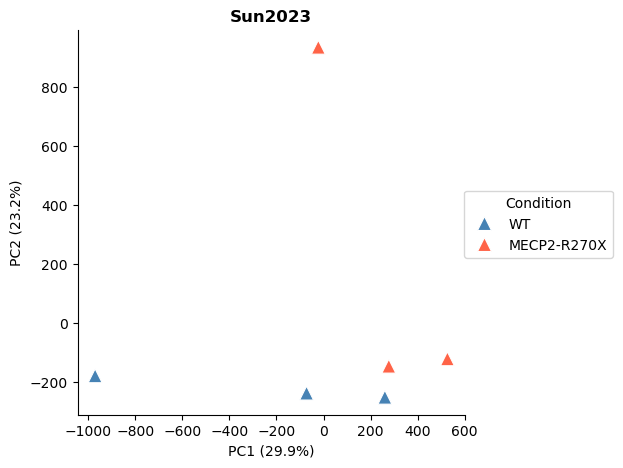

In [6]:
# Create figure
fig, ax = plt.subplots(figsize = (5,5))

palette_pca = {'WT' : 'steelblue',
               'MECP2-R270X' : 'tomato'}

pca_df['Condition'] = pca_df['Condition'].replace({"MECP2_R270X": "MECP2-R270X"})
sns.scatterplot(data = pca_df, x = 'PC1', y = 'PC2', palette = palette_pca, 
                hue = 'Condition', s = 100, marker ='^')


# Set labels and chart legend
ax.set_title('Sun2023', fontweight = 'bold', fontsize = 12)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.legend(title = 'Condition', bbox_to_anchor = (1.4, 0.6))

sns.despine()
plt.show()

Boxplot

In [7]:
# Assemble the new table
log2cpm_df.insert(0, 'TEs', TEs)
goi_df = log2cpm_df[log2cpm_df['TEs'].isin(genes_of_interest)]

long_df = goi_df.melt(id_vars = 'TEs', var_name = 'Sample_Name', value_name = 'log2(CPM)')
long_df = long_df.merge(clinical_data, on = 'Sample_Name', how = 'left')

print(clinical_data.head())

# Assemble the plot

fig, ax = plt.subplots(figsize = (12, 12))

palette_boxplot = {'MECP2_R270X' : 'tomato',
                   'WT' : 'steelblue'}

sns.boxplot(data = long_df, x = 'TEs', y = 'log2(CPM)', hue = 'Condition', palette = palette_boxplot,
                fliersize = 2, linewidth = 2)

ax.set_title('Boxplot - TEs - Sun2023', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('TEs')
ax.set_ylabel('log2(CPM)')
ax.tick_params(axis = 'x', rotation = 45)



TypeError: only list-like objects are allowed to be passed to isin(), you passed a `NoneType`